# Fetch data

## AnonDB Zubair

In [1]:
import pandas as pd
meta = pd.read_csv('AnonDB_with_Rs_I0_Rsh.csv', sep=';')
df_pixel_stats = pd.read_csv('pixel_stats.csv', sep=',')
meta_zub = pd.read_csv('AnonDB_zub.csv', sep=';')




In [2]:
meta.head()

,Unnamed: 0,Mod_ID,Confidential,Make,Model,Interconnect_Tech,Module_Area_(cm2),Junction_Box_Type,Cell_Wafer_Type,Cell_Tech,...,Ref_IV_Time,IL_fit,I0,Rs,Rsh,nNsVth_fit,V_column_used,I_column_used,fit_status,fit_error
0,0,3903,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:45:34,8.888586,2.800000e-10,0.318379,201.683997,1.589408,V,I,ok,NaN
1,1,3887,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,08:25:17,8.840692,7.780000e-10,0.307588,371.194847,1.654887,V,I,ok,NaN
2,2,3887,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,08:25:17,8.840173,5.180000e-10,0.334627,249.445806,1.628107,V,I,ok,NaN
3,3,3899,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:22:46,8.837768,5.430000e-10,0.310366,535.201004,1.631432,V,I,ok,NaN
4,4,3899,NaN,35,1,NaN,16222.6,NaN,mono-Si module,NaN,...,10:22:46,8.821158,8.960000e-10,0.333767,649.152218,1.666430,V,I,ok,NaN


In [3]:
df_pixel_stats.head()

,nama_gambar,mean,median,modus
0,10084_35_1_01272020_20_wrp.tiff,89.951571,95.0,102
1,10084_35_1_01272020_80_wrp.tiff,67.735187,70.0,70
2,10084_35_1_02222021_20_wrp.tiff,88.351796,105.0,5
3,10084_35_1_02222021_80_wrp.tiff,72.874862,85.0,6
4,10085_35_1_01272020_20_wrp.tiff,82.821786,86.0,77


In [4]:
df = df_pixel_stats.copy()

df["base_id"] = (
    df["nama_gambar"]
    .str.replace("_80_wrp.tiff", "", regex=False)
    .str.replace("_20_wrp.tiff", "", regex=False)
)


In [5]:
df_80 = df[df["nama_gambar"].str.contains("_80_wrp.tiff")].copy()
df_20 = df[df["nama_gambar"].str.contains("_20_wrp.tiff")].copy()


In [6]:
df_80 = df_80.rename(columns={
    "mean": "mean_80",
    "median": "median_80",
    "modus": "modus_80"
})

df_20 = df_20.rename(columns={
    "mean": "mean_20",
    "median": "median_20",
    "modus": "modus_20"
})


In [7]:
df_final = pd.merge(
    df_80[["base_id", "mean_80", "median_80", "modus_80"]],
    df_20[["base_id", "mean_20", "median_20", "modus_20"]],
    on="base_id",
    how="inner"
)


In [8]:
df_final.head()

,base_id,mean_80,median_80,modus_80,mean_20,median_20,modus_20
0,10084_35_1_01272020,67.735187,70.0,70,89.951571,95.0,102
1,10084_35_1_02222021,72.874862,85.0,6,88.351796,105.0,5
2,10085_35_1_01272020,64.001961,65.0,63,82.821786,86.0,77
3,10085_35_1_02222021,70.857794,82.0,6,86.758040,100.0,5
4,10105_24_3_03012021,91.260262,101.0,104,103.576085,116.0,8


In [9]:
# --- Calculate Performance Ratio (PR) ---
meta['PR'] = meta['Pmp_(W)'] / meta['Nameplate_Pmp_(W)'] * 100

In [10]:
meta2 = meta.copy()

meta2["base_id"] = (
    meta2["ELHPath"]
        .str.split("/")            # pisah folder
        .str[-1]                   # ambil nama file
        .str.replace(".tiff", "", regex=False)
        .str.replace("_80", "", regex=False)
        .str.replace("_20", "", regex=False)
)

# --- Calculate Performance Ratio (PR) ---
meta2['PR'] = meta2['Pmp_(W)'] / meta2['Nameplate_Pmp_(W)'] * 100

# -- Merge Meta2 with the pixel stats ---
meta_merged = meta2.merge(
    df_final,
    on="base_id",
    how="left"
)

df_final = meta_merged.merge(
    meta_zub[["Num_Cells", "ELHPath"]],
    on="ELHPath",
    how="left"
)

df_final['Total_Exposure_days'] = (
    df_final['Total_Exposure']
    .str.extract(r'(\d+)')   # ambil angka
    .astype(int)             # convert ke integer
)

df_final["Make_Model"] = (
    df_final["Make"].astype(str) + "_" + df_final["Model"].astype(str)
)


In [11]:
df_final['Total_Exposure_days'].head()

0     640
1     640
2    1024
3     640
4    1024
Name: Total_Exposure_days, dtype: int32

In [12]:
cols = [
    "PR",
    "mean_80", "median_80", "modus_80",
    "mean_20", "median_20", "modus_20"
]

correlation_matrix = meta_merged[cols].corr()

print(correlation_matrix["PR"].sort_values(ascending=False))


PR           1.000000
median_80    0.309684
mean_80      0.302513
modus_80     0.250620
modus_20     0.234074
median_20    0.062047
mean_20      0.049778
Name: PR, dtype: float64


In [13]:
pd.set_option('display.max_columns', None)

print(df_final.columns.tolist())

['Unnamed: 0', 'Mod_ID', 'Confidential', 'Make', 'Model', 'Interconnect_Tech', 'Module_Area_(cm2)', 'Junction_Box_Type', 'Cell_Wafer_Type', 'Cell_Tech', 'Cell_Area_(cm2)', 'Total_Exposure', 'Nameplate_Isc_(A)', 'Nameplate_Voc_(V)', 'Nameplate_Imp_(A)', 'Nameplate_Vmp_(V)', 'Nameplate_Pmp_(W)', 'Isc_(A)', 'Voc_(V)', 'Imp_(A)', 'Vmp_(V)', 'Pmp_(W)', 'FF_(percent)', 'Measured_Temperature_(C)', 'Temp_Measurement_Method', 'Voltage_Temperature_Coefficient_(mV/C)', 'Simulator_Make', 'Simulator_Model', 'IV_Date', 'IV_Time', 'IV_Lab_Location', 'Camera_Make', 'Camera_Model', 'Detector_Type', 'Image_Resolution_(MP)', 'Longpass_Filter_Wavelength_(nm)', 'High_Applied_Current_(A)', 'High_Applied_Voltage_(V)', 'High_Sensor_Exposure_Time_(s)', 'Low_Applied_Current_(A)', 'Low_Applied_Voltage_(V)', 'Low_Sensor_Exposure_Time_(s)', 'ISO', 'Aperture', 'High_Temperature_(C)', 'Low_Temperature_(C)', 'Working_Distance_(m)', 'High_EL_Date', 'High_EL_Time', 'Low_EL_Date', 'Low_EL_Time', 'EL_Lab_Location', 'ELHP

# 1. Pairplot

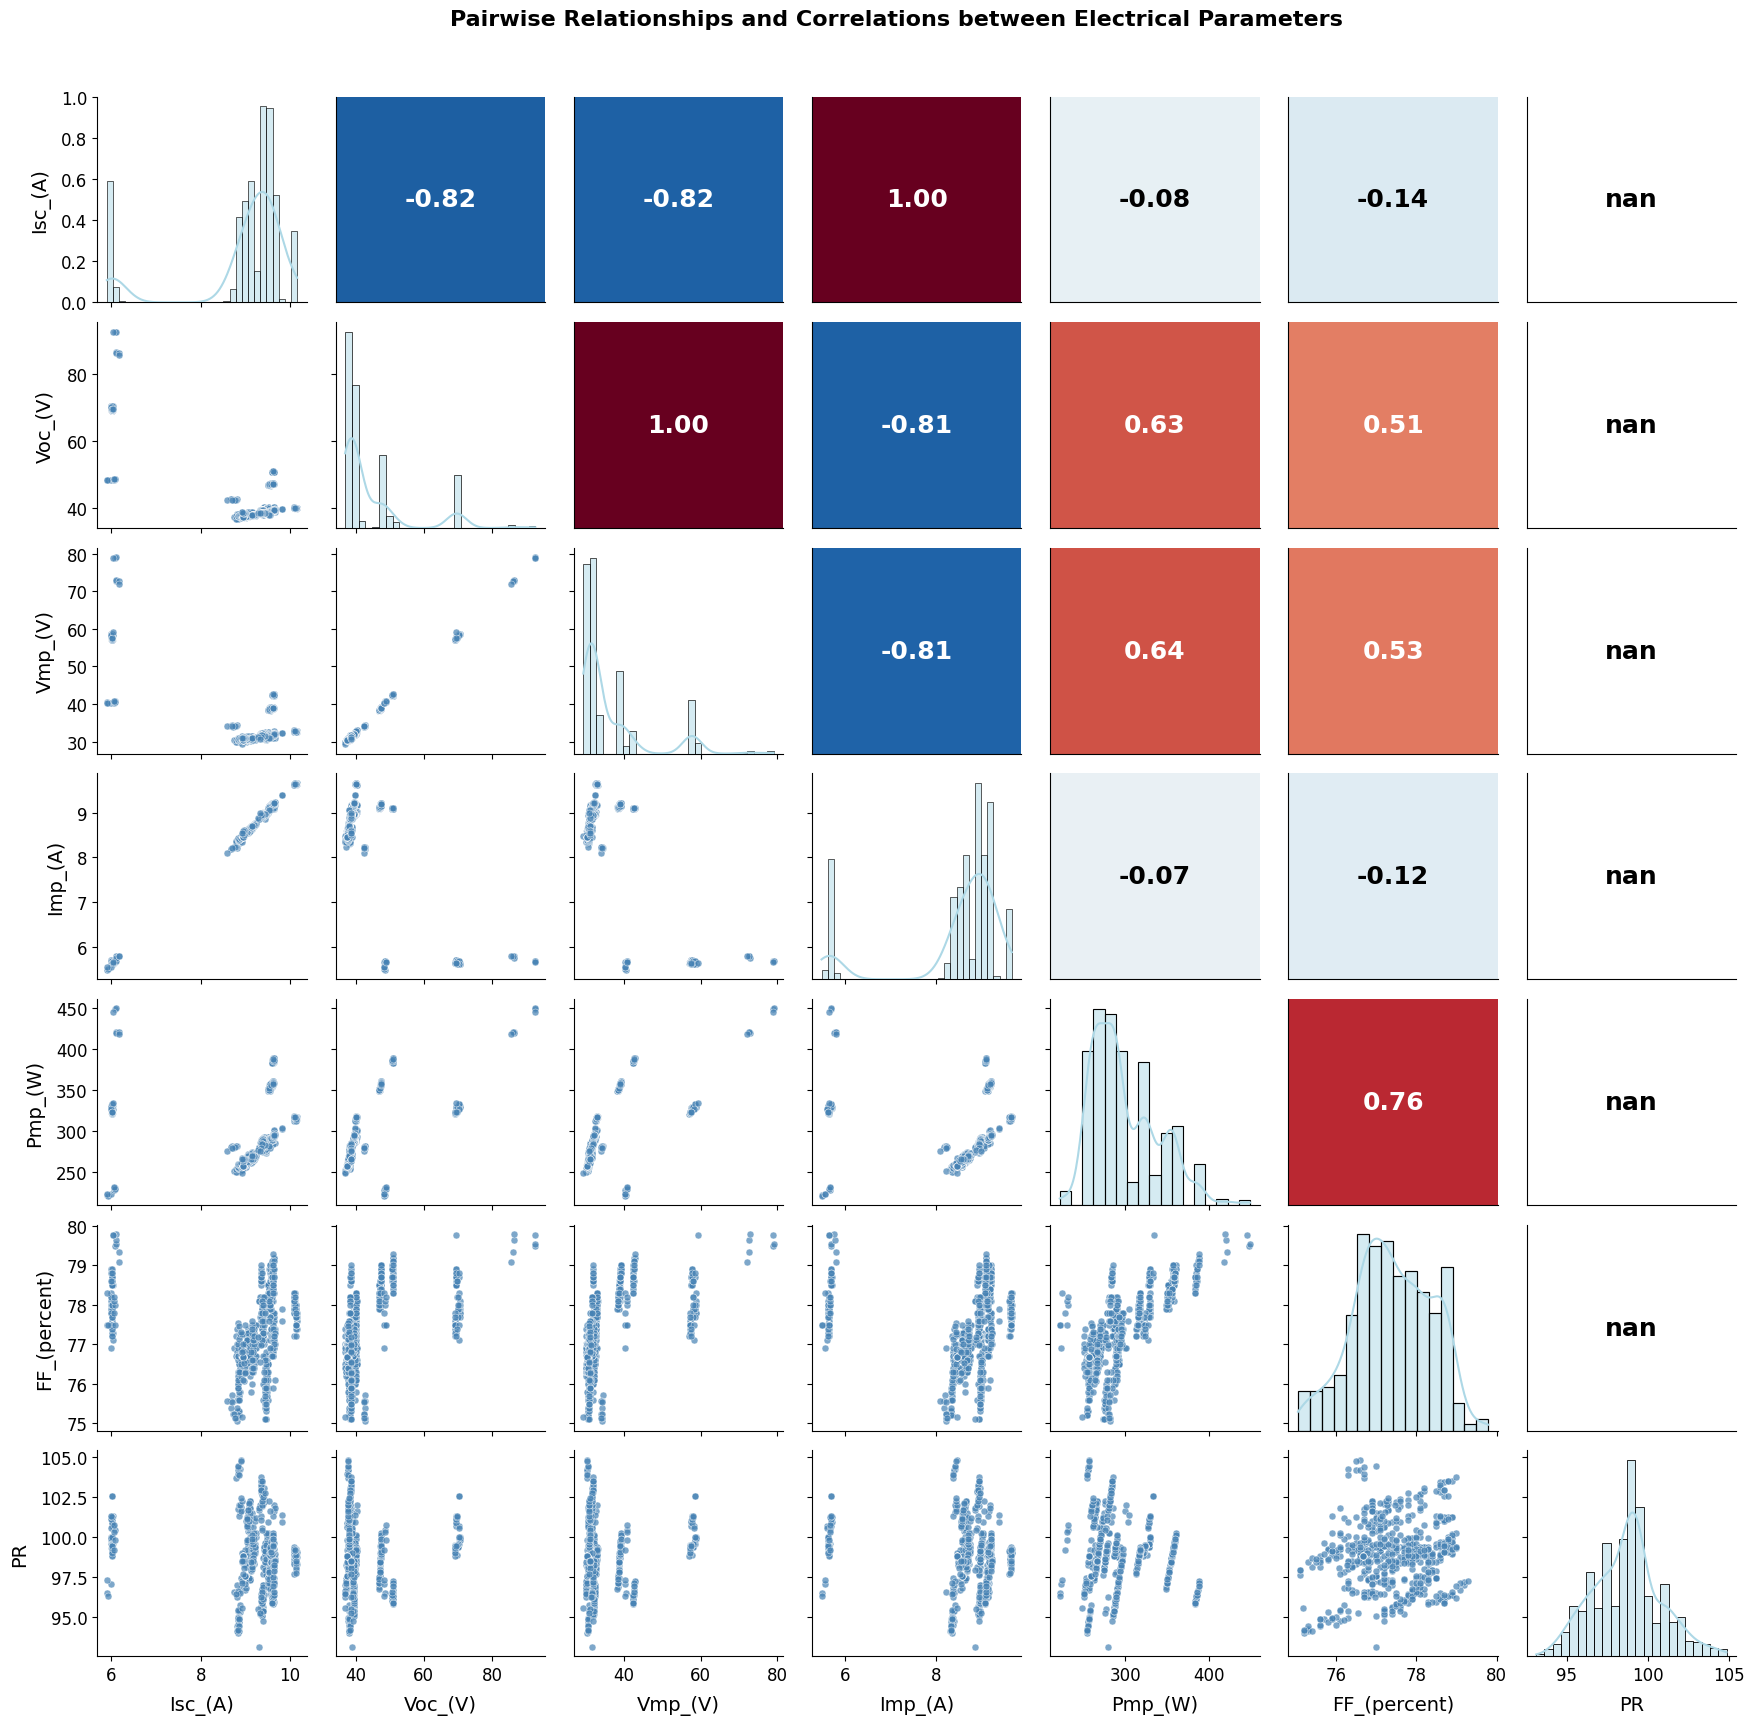

In [14]:

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cols = ['Isc_(A)', 'Voc_(V)', 'Vmp_(V)', 'Imp_(A)', 'Pmp_(W)', 'FF_(percent)', 'PR']
df = df_final[cols].copy()

# === Create PairGrid ===
g = sns.PairGrid(df, diag_sharey=False)

# Lower triangle → scatter
g.map_lower(sns.scatterplot, s=25, color="steelblue", alpha=0.7)

# Upper triangle → correlation + colored background
def corr_heatmap(x, y, **kwargs):
    ax = plt.gca()
    r = np.corrcoef(x, y)[0, 1]
    cmap = plt.cm.RdBu_r
    ax.set_facecolor(cmap((r + 1) / 2))
    # Hide ticks inside upper triangle only
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    # Display correlation number
    ax.text(0.5, 0.5, f"{r:.2f}",
            ha='center', va='center',
            fontsize=18, fontweight='bold',
            color='white' if abs(r) > 0.5 else 'black',
            transform=ax.transAxes)

g.map_upper(corr_heatmap)

# Diagonal → histograms
g.map_diag(sns.histplot, kde=True, color="lightblue")

# === Style and labels ===
for i, label in enumerate(cols):
    g.axes[-1, i].set_xlabel(label, fontsize=14, labelpad=8)
    g.axes[i, 0].set_ylabel(label, fontsize=14, labelpad=8)

# Make tick labels larger (scatter/hist only)
for ax in g.axes.flatten():
    ax.tick_params(axis='both', labelsize=12)

plt.subplots_adjust(top=0.93)
g.fig.suptitle("Pairwise Relationships and Correlations between Electrical Parameters",
               fontsize=16, fontweight='bold')

plt.show()


# 2. Color Scatter Plot

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_scatter(df, x_axis, y_axis, different_color=None, add_regression=True):
    """
    Scatter plot dengan opsi grouping warna dan regression line
    
    Parameters:
    df : DataFrame
    x_axis : str (nama kolom untuk sumbu X)
    y_axis : str (nama kolom untuk sumbu Y)
    different_color : str (opsional, kolom untuk grouping warna)
    add_regression : bool (default True)
    """
    
    # Drop NaN biar clean
    cols = [x_axis, y_axis]
    if different_color:
        cols.append(different_color)
        
    df_clean = df[cols].dropna()

    plt.figure(figsize=(8,6))

    if different_color:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            hue=different_color,
            palette='tab10',
            s=70
        )
    else:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            s=70
        )

    # Regression line
    if add_regression:
        sns.regplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            scatter=False,
            color='black',
            line_kws={'linewidth': 2}
        )

        # Correlation
        corr = df_clean[x_axis].corr(df_clean[y_axis])
        plt.title(f"{y_axis} vs {x_axis} (corr = {corr:.3f})")
    else:
        plt.title(f"{y_axis} vs {x_axis}")

    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_scatter(df, x_axis, y_axis, different_color=None, add_regression=True,
                 log_x=False, log_y=False):

    import matplotlib.pyplot as plt
    import seaborn as sns

    cols = [x_axis, y_axis]
    if different_color:
        cols.append(different_color)
        
    df_clean = df[cols].dropna()

    # 🔥 FILTER kalau pakai log
    if log_x:
        df_clean = df_clean[df_clean[x_axis] > 0]
    if log_y:
        df_clean = df_clean[df_clean[y_axis] > 0]

    plt.figure(figsize=(8,6))

    # 🎨 Scatter dengan atau tanpa warna
    if different_color:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            hue=different_color,
            palette='tab10',
            s=70
        )
    else:
        sns.scatterplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            s=70
        )

    # 📈 Regression line (global, tidak per warna)
    if add_regression:
        sns.regplot(
            data=df_clean,
            x=x_axis,
            y=y_axis,
            scatter=False,
            color='black',
            line_kws={'linewidth': 2}
        )

        corr = df_clean[x_axis].corr(df_clean[y_axis])
        title = f"{y_axis} vs {x_axis} (corr = {corr:.3f})"
    else:
        title = f"{y_axis} vs {x_axis}"

    # ⚙️ LOG SCALE
    if log_x:
        plt.xscale('log')
    if log_y:
        plt.yscale('log')

    plt.title(title)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.grid(True, which="both", linestyle='--', linewidth=0.5)

    if different_color:
        plt.legend(title=different_color)

    plt.tight_layout()
    plt.show()

In [17]:
#df_final['Make_Model'].value_counts()
#df_final[df_final['Make_Model'] == "20_1"]

#df_final['Rsh'].describe()
df_final[(df_final['Num_Cells'] == "shingle") ].count()

Unnamed: 0             26
Mod_ID                 26
Confidential            0
Make                   26
Model                  26
                       ..
median_20              26
modus_20               26
Num_Cells              26
Total_Exposure_days    26
Make_Model             26
Length: 83, dtype: int64

In [54]:
df_final['Make_Model'].value_counts()

Make_Model
12_1     97
20_1     62
22_3     56
17_1     48
5_5      35
5_6      33
25_3     31
15_3     31
35_1     27
25_4     27
32_2     26
24_4     26
15_2     24
24_2     19
22_4     19
15_1     18
34_8     16
38_4     16
24_3     15
34_5     10
5_8      10
25_1     10
7_1       9
36_1      9
38_2      9
34_4      8
30_4      6
30_1      4
34_10     3
36_4      2
36_7      2
36_5      2
36_6      2
Name: count, dtype: int64

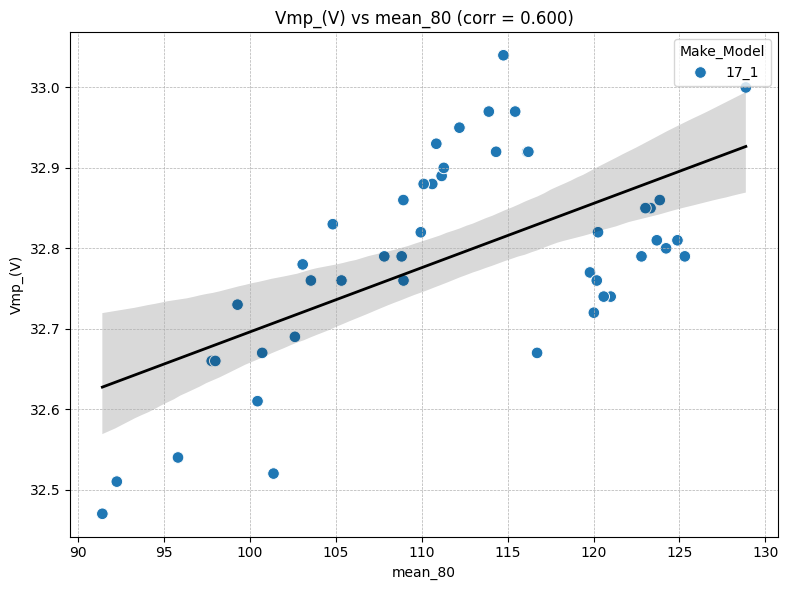

In [65]:
plot_scatter(
    df_final[(df_final['Make_Model'] == '17_1')], #[(df_final['Make_Model'] != '25_4') & (df_final['Make_Model'] != '7_1')], #[(df_final['mean_80'] < df_final['Vmp_(V)'].quantile(0.95)) ], #df dengan filter 
    x_axis='mean_80',
    y_axis='Vmp_(V)',
    different_color='Make_Model',
    log_x=False,
    log_y=False
)

In [ ]:
import plotly.express as px
import nbformat as nb

def plot_scatter_plotly(df, x_axis, y_axis, color=None):
    fig = px.scatter(
        df,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_data=df.columns,  # semua info muncul saat hover
        title=f"{y_axis} vs {x_axis}",
        template="plotly_white"
    )

    fig.show()

In [ ]:
import plotly.express as px

def plot_scatter_plotly(df, x_axis, y_axis, color=None, hover_name=None, save_html=None):
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        trendline="ols",
        template="plotly_white",
        title=f"{y_axis} vs {x_axis}"
    )

    if save_html:
        fig.write_html(save_html, auto_open=True)
    else:
        from plotly.offline import plot
        plot(fig, auto_open=True)

In [ ]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import plot

def plot_scatter_quadratic(df, x_axis, y_axis, color=None, hover_name=None):
    
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    # Scatter plot
    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        template="plotly_white",
        title=f"{y_axis} vs {x_axis} (Quadratic Fit)"
    )

    # Quadratic fit
    x = df_clean[x_axis].astype(float).values
    y = df_clean[y_axis].astype(float).values

    if len(x) >= 3:
        coeffs = np.polyfit(x, y, 2)  # 🔥 degree 2
        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = coeffs[0]*x_line**2 + coeffs[1]*x_line + coeffs[2]

        fig.add_trace(
            go.Scatter(
                x=x_line,
                y=y_line,
                mode="lines",
                name="Quadratic Fit",
                line=dict(color="black", width=3)
            )
        )

    plot(fig, auto_open=True)

In [ ]:
plot_scatter_quadratic(
    df=meta_merged,
    x_axis="mean_80",
    y_axis="PR",
    color="Make_Model",
    hover_name="Model"
)

In [ ]:
import pandas as pd

df_num = meta_merged.select_dtypes(include=["number"])
corr = df_num.corr(method="spearman")

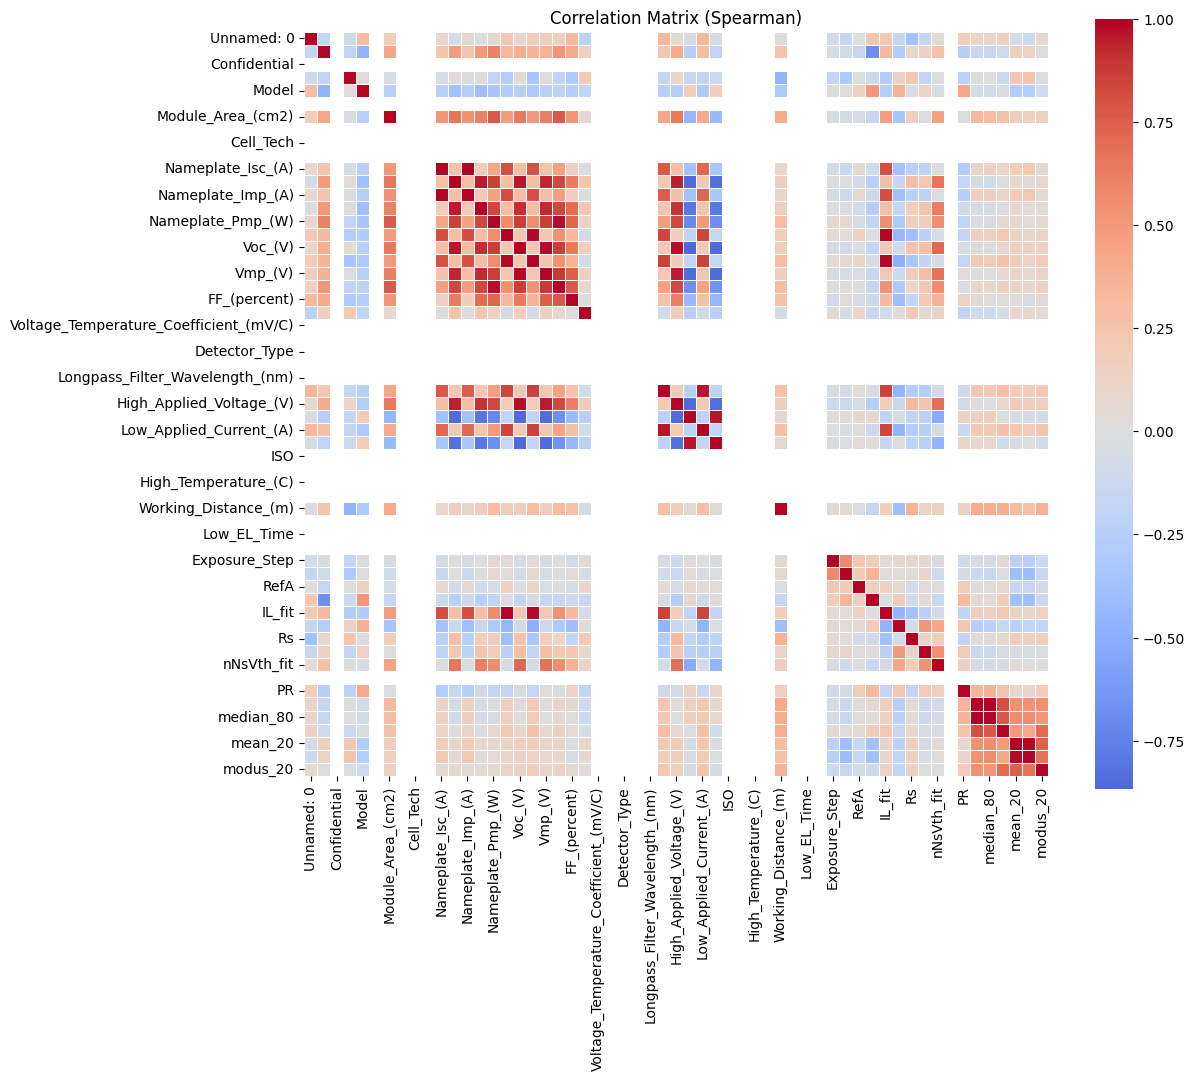

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix (Spearman)")
plt.show()

In [ ]:
meta_merged[["mean_80", "mean_80_norm", "PR"]].corr(method="spearman")

#print(corr_target)

KeyError: "['mean_80_norm'] not in index"

In [ ]:
meta_merged["mean_80_norm"] = meta_merged["mean_80"] * (meta_merged["Working_Distance_(m)"])

In [ ]:
meta_merged[["mean_80", "Rs"]].corr(method="spearman")

,mean_80,Rs
mean_80,1.000000,0.038138
Rs,0.038138,1.000000


In [ ]:
corr["Pmp_(W)"].sort_values(ascending=False)

Pmp_(W)                                   1.000000
Nameplate_Pmp_(W)                         0.975277
Vmp_(V)                                   0.878702
Voc_(V)                                   0.867568
Nameplate_Vmp_(V)                         0.833656
Nameplate_Voc_(V)                         0.833065
High_Applied_Voltage_(V)                  0.830794
Module_Area_(cm2)                         0.772153
FF_(percent)                              0.769517
nNsVth_fit                                0.556657
Imp_(A)                                   0.538985
Isc_(A)                                   0.531276
IL_fit                                    0.527141
Mod_ID                                    0.515851
Nameplate_Imp_(A)                         0.479774
Nameplate_Isc_(A)                         0.461267
Low_Applied_Current_(A)                   0.453556
High_Applied_Current_(A)                  0.450621
Working_Distance_(m)                      0.299234
Rsh                            

In [ ]:
import sys
import plotly
import plotly.io as pio
import nbformat
import IPython

print("Python:", sys.executable)
print("Plotly:", plotly.__version__)
print("nbformat:", nbformat.__version__)
print("IPython:", IPython.__version__)
print("Default renderer:", pio.renderers.default)
print(pio.renderers)

Python: c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\python.exe
Plotly: 6.6.0
nbformat: 5.10.4
IPython: 8.30.0
Default renderer: vscode
Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [ ]:
import plotly.io as pio

pio.renderers.default = "browser"
print("Renderer aktif:", pio.renderers.default)

Renderer aktif: browser


In [ ]:
import plotly.express as px

fig = px.scatter(
    meta_merged.dropna(subset=["mean_80", "PR"]),
    x="mean_80",
    y="PR",
    color="Make_Model",
    template="plotly"
)

fig.show(renderer="browser")

In [ ]:
import plotly.express as px

def plot_scatter_plotly_browser(df, x_axis, y_axis, color=None, hover_name=None, filename="scatter_plot.html"):
    cols = [x_axis, y_axis]
    if color:
        cols.append(color)
    if hover_name and hover_name not in cols:
        cols.append(hover_name)

    df_clean = df[cols].dropna().copy()

    fig = px.scatter(
        df_clean,
        x=x_axis,
        y=y_axis,
        color=color,
        hover_name=hover_name,
        hover_data=df_clean.columns,
        template="plotly_white",
        title=f"{y_axis} vs {x_axis}"
    )

    fig.write_html(filename, auto_open=True)

In [ ]:
import plotly.express as px

fig = px.scatter(
    meta_merged.dropna(subset=["mean_80", "PR"]),
    x="mean_80",
    y="PR",
    color="Make_Model",
    template="plotly",
    color_discrete_sequence=px.colors.qualitative.Alphabet  # 🔥 lebih banyak warna
)

fig.show(renderer="browser")

Saved chart: corrected_comparison_charts\Rs_module_total_per60_vs_Rs.png


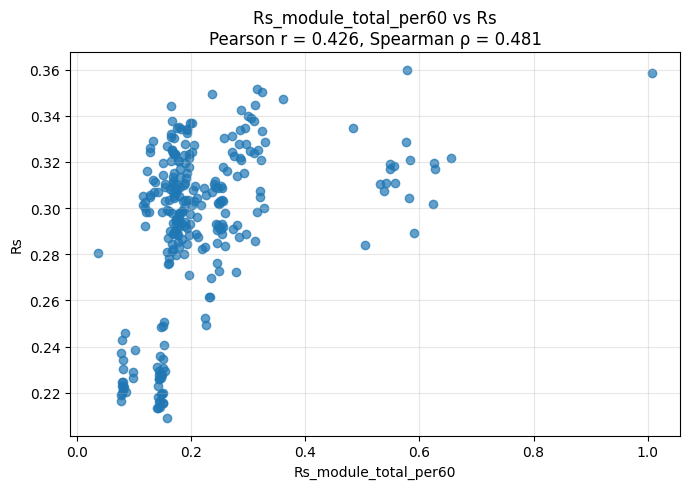

Saved chart: corrected_comparison_charts\Rs_module_mean_per60_vs_Rs.png


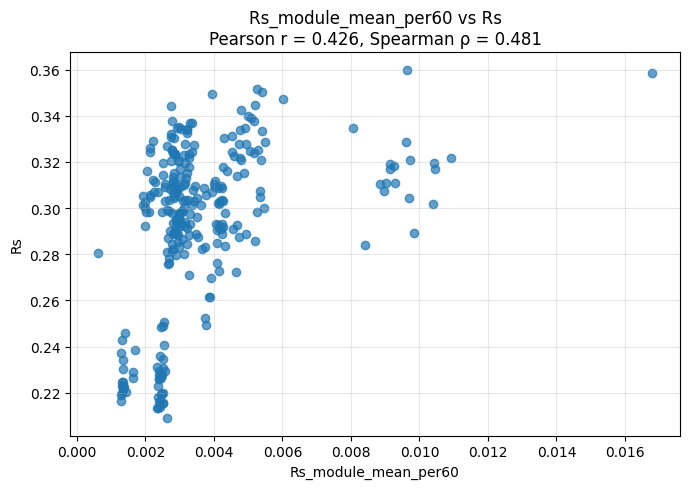

Skipped: kolom Rs_module_median_per60 tidak ditemukan
Saved chart: corrected_comparison_charts\J0_module_avg_per60_vs_I0.png


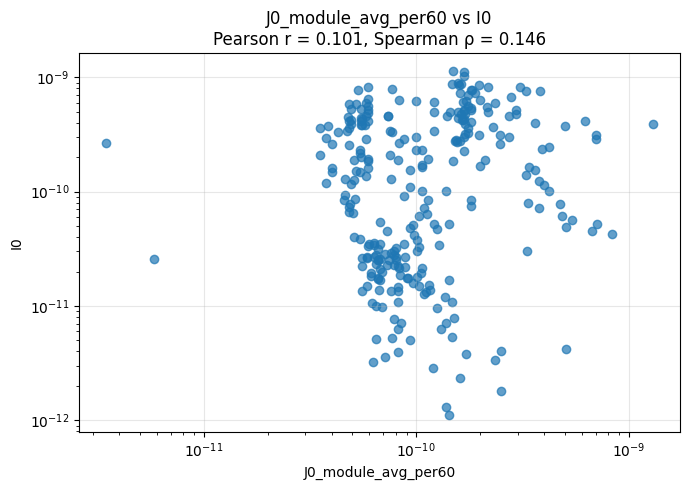

Saved chart: corrected_comparison_charts\J0_module_median_per60_vs_I0.png


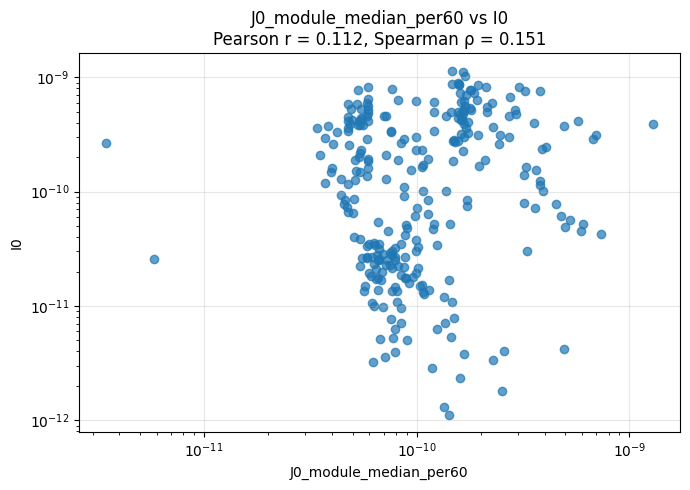


Correlation summary:
                    x_col y_col    n  pearson_r     pearson_p  spearman_rho  \
0   Rs_module_total_per60    Rs  274   0.425983  1.664524e-13      0.481099   
1    Rs_module_mean_per60    Rs  274   0.425983  1.664524e-13      0.481099   
2     J0_module_avg_per60    I0  274   0.101070  9.499293e-02      0.146174   
3  J0_module_median_per60    I0  274   0.112102  6.388588e-02      0.150622   

     spearman_p  
0  2.804221e-17  
1  2.804221e-17  
2  1.545398e-02  
3  1.255708e-02  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

# =========================
# 1. Load data
# =========================
df = pd.read_csv("merged_sdm.csv")  # ganti sesuai nama file kamu

# =========================
# 2. Kolom yang dipakai
# =========================
rs_cols = [
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median"
]

j0_cols = [
    "J0_module_avg",
    "J0_module_median"
]

base_cols = [
    "vals_size",
    "Rs",
    "I0"
]

all_cols = rs_cols + j0_cols + base_cols

# =========================
# 3. Convert ke numeric
# =========================
for col in all_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4. Buat kolom hasil koreksi
# =========================
# Rs: dibagi vals_size lalu dikali 60
for col in rs_cols:
    if col in df.columns:
        new_col = f"{col}_per60"
        df[new_col] = df[col] / df["vals_size"] * 60

# J0: dikali vals_size lalu dibagi 60
for col in j0_cols:
    if col in df.columns:
        new_col = f"{col}_per60"
        df[new_col] = df[col] * df["vals_size"] / 60

# =========================
# 5. Fungsi visualisasi + korelasi
# =========================
def plot_comparison(df, x_col, y_col, log_x=False, log_y=False, save=True):
    if x_col not in df.columns:
        print(f"Skipped: kolom {x_col} tidak ditemukan")
        return None
    
    if y_col not in df.columns:
        print(f"Skipped: kolom {y_col} tidak ditemukan")
        return None

    data = df[[x_col, y_col]].dropna()

    if log_x:
        data = data[data[x_col] > 0]
    if log_y:
        data = data[data[y_col] > 0]

    if len(data) < 3:
        print(f"Skipped: data valid terlalu sedikit untuk {x_col} vs {y_col}")
        return None

    x = data[x_col]
    y = data[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.title(
        f"{x_col} vs {y_col}\n"
        f"Pearson r = {pearson_r:.3f}, Spearman ρ = {spearman_rho:.3f}"
    )

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        output_dir = Path("corrected_comparison_charts")
        output_dir.mkdir(exist_ok=True)

        filename = f"{x_col}_vs_{y_col}.png".replace("/", "_")
        save_path = output_dir / filename
        plt.savefig(save_path, dpi=300)
        print(f"Saved chart: {save_path}")

    plt.show()

    return {
        "x_col": x_col,
        "y_col": y_col,
        "n": len(data),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }

# =========================
# 6. Plot Rs corrected vs Rs
# =========================
results = []

for col in rs_cols:
    corrected_col = f"{col}_per60"
    result = plot_comparison(
        df,
        x_col=corrected_col,
        y_col="Rs",
        log_x=False,
        log_y=False
    )
    if result is not None:
        results.append(result)

# =========================
# 7. Plot J0 corrected vs I0
# Pakai log scale karena J0 dan I0 biasanya sangat kecil
# =========================
for col in j0_cols:
    corrected_col = f"{col}_per60"
    result = plot_comparison(
        df,
        x_col=corrected_col,
        y_col="I0",
        log_x=True,
        log_y=True
    )
    if result is not None:
        results.append(result)

# =========================
# 8. Simpan ringkasan korelasi
# =========================
corr_summary = pd.DataFrame(results)
corr_summary.to_csv("corrected_correlation_summary.csv", index=False)

print("\nCorrelation summary:")
print(corr_summary)

Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_make_code.png


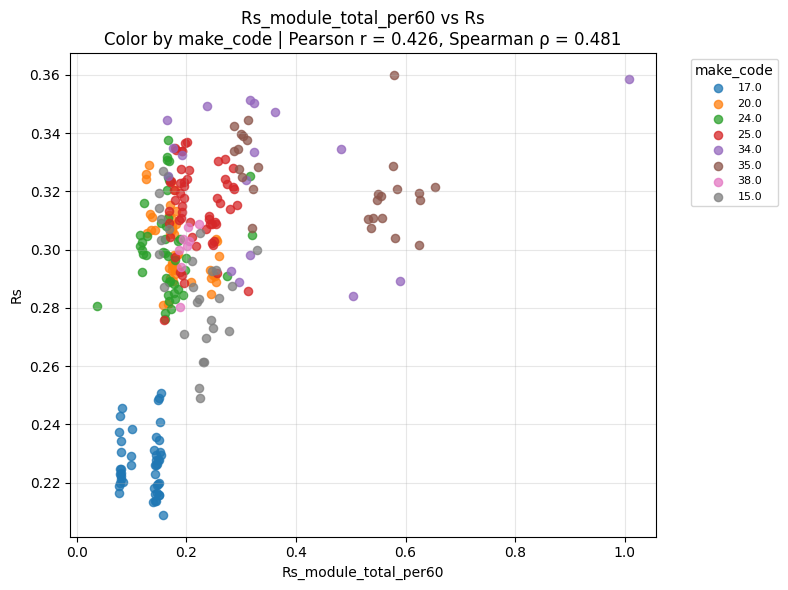

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_make_code.png


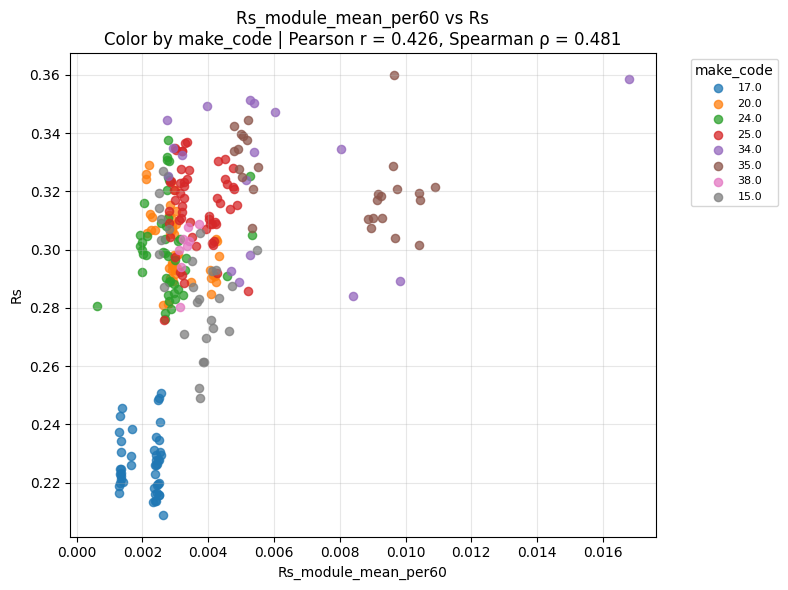

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_model_code.png


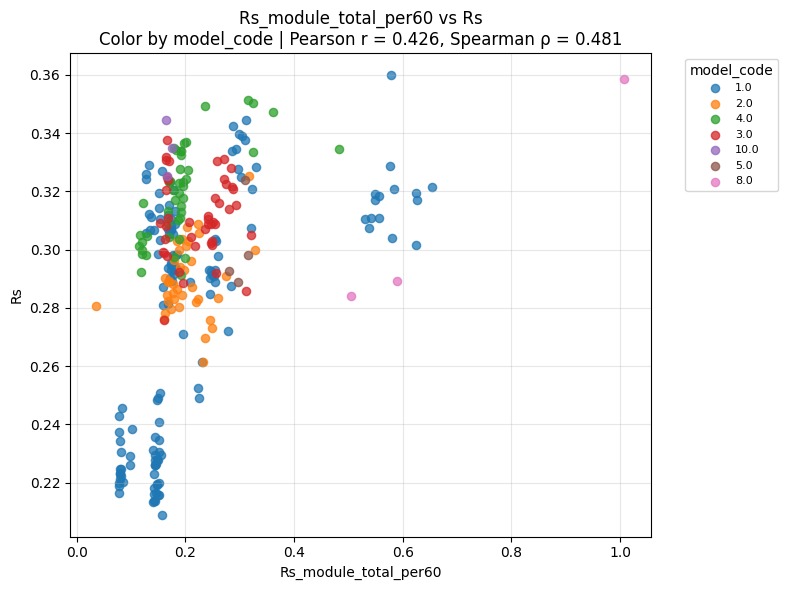

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_model_code.png


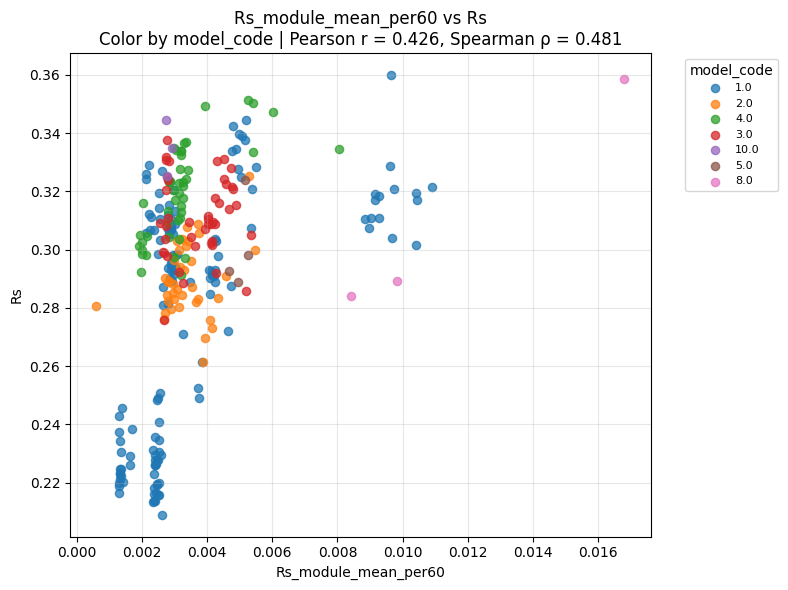

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\Rs_module_total_per60_vs_Rs_by_make_model.png


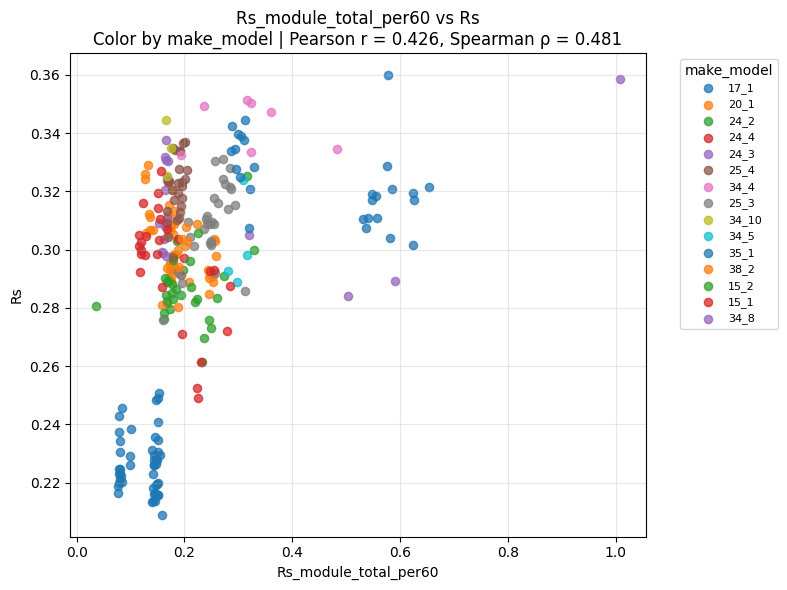

Saved chart: colored_comparison_charts\Rs_module_mean_per60_vs_Rs_by_make_model.png


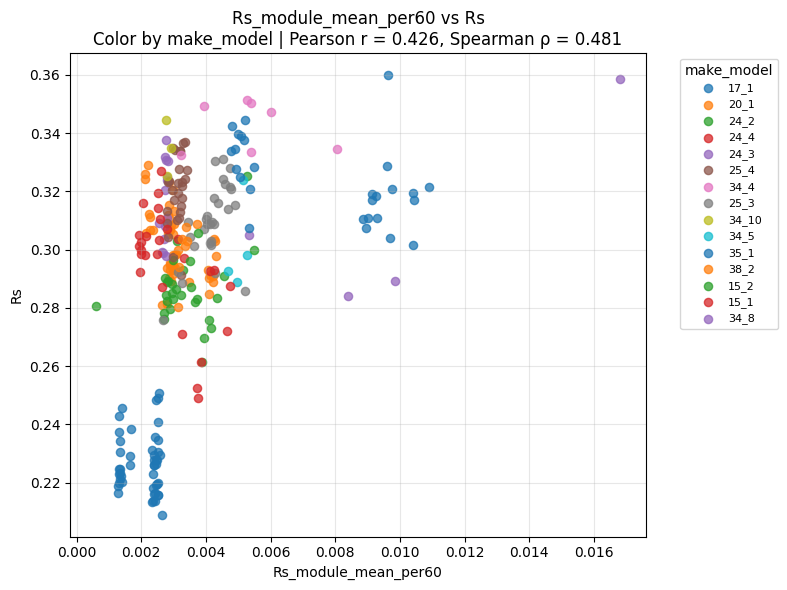

Skipped: Rs_module_median_per60 tidak ditemukan
Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_make_code.png


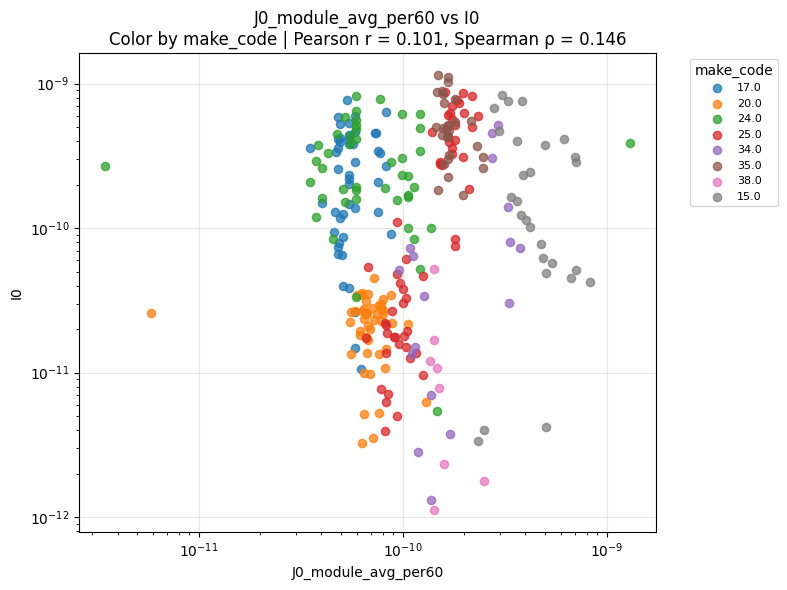

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_make_code.png


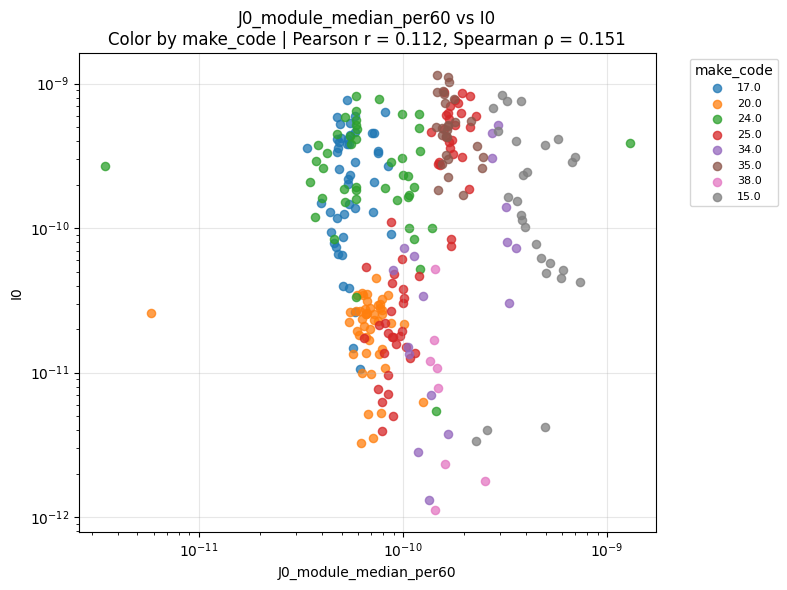

Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_model_code.png


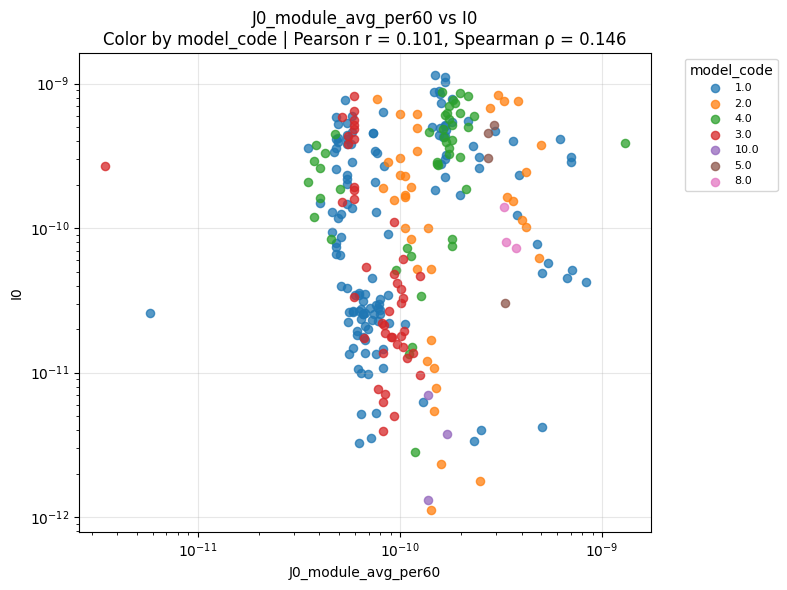

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_model_code.png


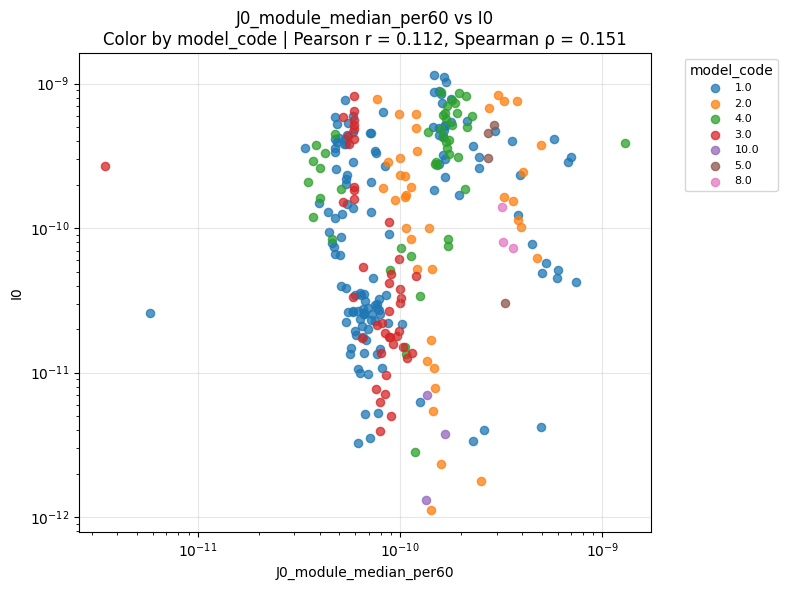

Saved chart: colored_comparison_charts\J0_module_avg_per60_vs_I0_by_make_model.png


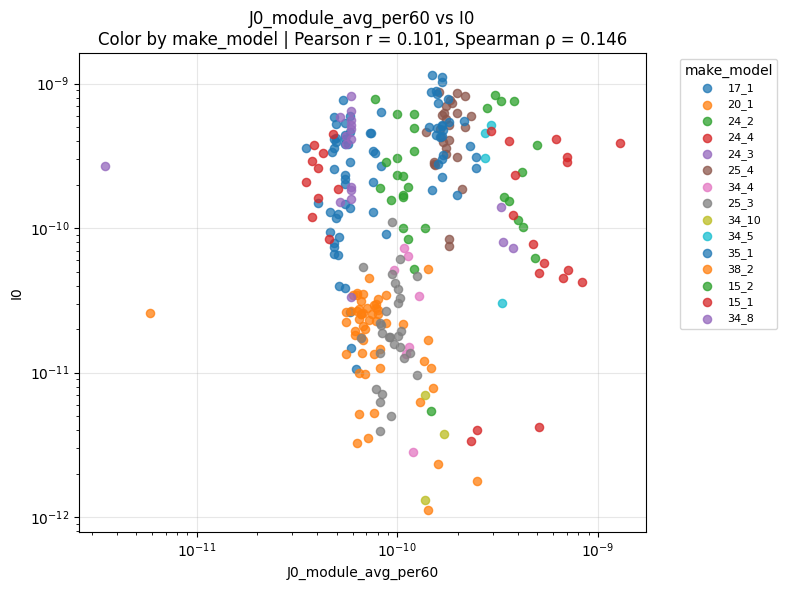

Saved chart: colored_comparison_charts\J0_module_median_per60_vs_I0_by_make_model.png


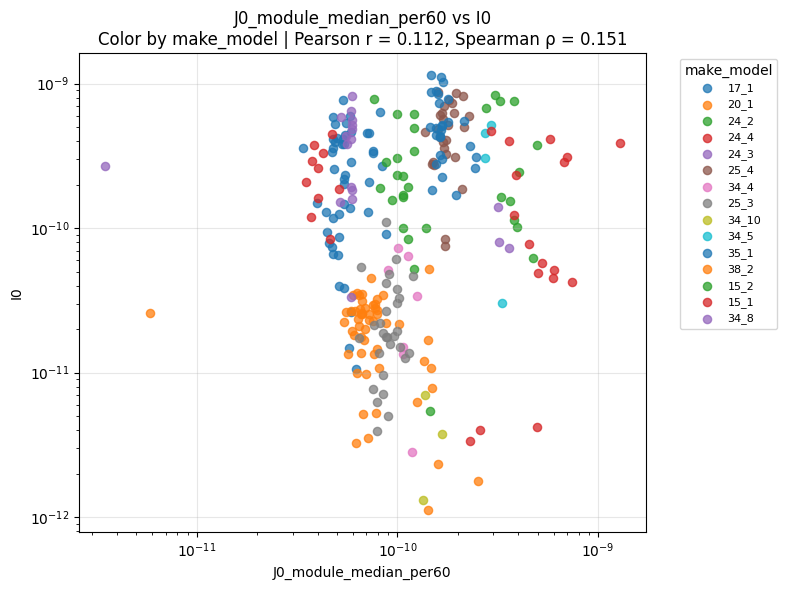

Saved dataset: merged_inner_split_corrected.csv
Saved correlation summary: colored_correlation_summary.csv
                     x_col y_col   color_col    n  pearson_r     pearson_p  \
0    Rs_module_total_per60    Rs   make_code  274   0.425983  1.664524e-13   
1     Rs_module_mean_per60    Rs   make_code  274   0.425983  1.664524e-13   
2    Rs_module_total_per60    Rs  model_code  274   0.425983  1.664524e-13   
3     Rs_module_mean_per60    Rs  model_code  274   0.425983  1.664524e-13   
4    Rs_module_total_per60    Rs  make_model  274   0.425983  1.664524e-13   
5     Rs_module_mean_per60    Rs  make_model  274   0.425983  1.664524e-13   
6      J0_module_avg_per60    I0   make_code  274   0.101070  9.499293e-02   
7   J0_module_median_per60    I0   make_code  274   0.112102  6.388588e-02   
8      J0_module_avg_per60    I0  model_code  274   0.101070  9.499293e-02   
9   J0_module_median_per60    I0  model_code  274   0.112102  6.388588e-02   
10     J0_module_avg_per60    I0  m

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

# =========================
# 1. Load data
# =========================
df = pd.read_csv("merged_sdm.csv")  # ganti sesuai nama file kamu

# =========================
# 2. Pecah kolom module
# contoh: 3395_30_1_03182016
# =========================
module_split = df["module"].astype(str).str.extract(
    r"(?P<module_id>[^_]+)_(?P<make_code>[^_]+)_(?P<model_code>[^_]+)_(?P<date_raw>\d+)"
)

df = pd.concat([df, module_split], axis=1)

# ubah date_raw ke datetime
df["date"] = pd.to_datetime(df["date_raw"], format="%m%d%Y", errors="coerce")

# gabungan make dan model
df["make_model"] = df["make_code"].astype(str) + "_" + df["model_code"].astype(str)

# optional: kalau mau module_id/make/model jadi numeric
df["module_id"] = pd.to_numeric(df["module_id"], errors="coerce")
df["make_code"] = pd.to_numeric(df["make_code"], errors="coerce")
df["model_code"] = pd.to_numeric(df["model_code"], errors="coerce")

# =========================
# 3. Convert kolom penting ke numeric
# =========================
cols_to_numeric = [
    "vals_size",
    "Rs",
    "I0",
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median",
    "J0_module_avg",
    "J0_module_median"
]

for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4. Buat kolom corrected
# =========================
rs_cols = [
    "Rs_module_total",
    "Rs_module_mean",
    "Rs_module_median"
]

j0_cols = [
    "J0_module_avg",
    "J0_module_median"
]

for col in rs_cols:
    if col in df.columns:
        df[f"{col}_per60"] = df[col] / df["vals_size"] * 60

for col in j0_cols:
    if col in df.columns:
        df[f"{col}_per60"] = df[col] * df["vals_size"] / 60

# =========================
# 5. Fungsi scatter plot dengan warna kategori
# =========================
def plot_colored_scatter(
    df,
    x_col,
    y_col,
    color_col,
    log_x=False,
    log_y=False,
    min_group_count=1,
    save=True
):
    if x_col not in df.columns:
        print(f"Skipped: {x_col} tidak ditemukan")
        return None

    if y_col not in df.columns:
        print(f"Skipped: {y_col} tidak ditemukan")
        return None

    if color_col not in df.columns:
        print(f"Skipped: {color_col} tidak ditemukan")
        return None

    data = df[[x_col, y_col, color_col]].dropna()

    if log_x:
        data = data[data[x_col] > 0]
    if log_y:
        data = data[data[y_col] > 0]

    # optional filter: buang kategori yang datanya terlalu sedikit
    group_counts = data[color_col].value_counts()
    valid_groups = group_counts[group_counts >= min_group_count].index
    data = data[data[color_col].isin(valid_groups)]

    if len(data) < 3:
        print(f"Skipped: data valid terlalu sedikit untuk {x_col} vs {y_col}")
        return None

    x = data[x_col]
    y = data[y_col]

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    plt.figure(figsize=(8, 6))

    categories = data[color_col].astype(str).unique()

    for cat in categories:
        subset = data[data[color_col].astype(str) == cat]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            alpha=0.75,
            label=str(cat),
            s=35
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.title(
        f"{x_col} vs {y_col}\n"
        f"Color by {color_col} | Pearson r = {pearson_r:.3f}, Spearman ρ = {spearman_rho:.3f}"
    )

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.grid(True, alpha=0.3)

    # Legend dibuat di luar plot supaya tidak nutup data
    plt.legend(
        title=color_col,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()

    if save:
        output_dir = Path("colored_comparison_charts")
        output_dir.mkdir(exist_ok=True)

        filename = f"{x_col}_vs_{y_col}_by_{color_col}.png"
        filename = filename.replace("/", "_")
        save_path = output_dir / filename

        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved chart: {save_path}")

    plt.show()

    return {
        "x_col": x_col,
        "y_col": y_col,
        "color_col": color_col,
        "n": len(data),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p
    }

# =========================
# 6. Buat semua plot:
#    warna berdasarkan make_code, model_code, make_model
# =========================
results = []

color_cols = [
    "make_code",
    "model_code",
    "make_model"
]

rs_corrected_cols = [
    "Rs_module_total_per60",
    "Rs_module_mean_per60",
    "Rs_module_median_per60"
]

j0_corrected_cols = [
    "J0_module_avg_per60",
    "J0_module_median_per60"
]

# Rs plots
for color_col in color_cols:
    for x_col in rs_corrected_cols:
        result = plot_colored_scatter(
            df,
            x_col=x_col,
            y_col="Rs",
            color_col=color_col,
            log_x=False,
            log_y=False,
            min_group_count=1
        )
        if result is not None:
            results.append(result)

# J0 plots
for color_col in color_cols:
    for x_col in j0_corrected_cols:
        result = plot_colored_scatter(
            df,
            x_col=x_col,
            y_col="I0",
            color_col=color_col,
            log_x=True,
            log_y=True,
            min_group_count=1
        )
        if result is not None:
            results.append(result)

# =========================
# 7. Simpan dataset dan ringkasan korelasi
# =========================
df.to_csv("merged_inner_split_corrected.csv", index=False)

corr_summary = pd.DataFrame(results)
corr_summary.to_csv("colored_correlation_summary.csv", index=False)

print("Saved dataset: merged_inner_split_corrected.csv")
print("Saved correlation summary: colored_correlation_summary.csv")
print(corr_summary)